## Week Four: Random Forest Regressor

Same target, same cleaned data as the decision tree notebook, different model. A single decision tree is
easy to read but prone to memorizing quirks of the training data — grow it deep enough to be accurate and
it overfits, keep it shallow enough to generalize and it underfits. A random forest is a bundle of many
trees, each trained on a random subset of rows (bagging) and a random subset of features at each split,
with predictions averaged across all of them. That averaging is the whole point: individual trees'
mistakes tend to cancel out rather than compound, so the forest is usually more accurate and more stable
than any one tree, at the cost of losing the "read the whole decision path" interpretability a single
tree gives you, and being slower to train and predict.

I'm reusing the exact same feature preparation as the decision tree notebook (same drop columns, same
price sanity filter, same encoding) so the two models are comparable on identical inputs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree

df_trained = pd.read_csv('train_housing.csv')
df_test = pd.read_csv('test_housing.csv')

df_trained.head()

## Prepare the features

Same reasoning as the decision tree notebook - see that notebook for the full explanation of each choice.
In short: drop the target, dates, pure ID columns, and columns that are constant after filtering to
single-family residential; drop rows with a missing or implausible (<=$0 or >$50M) `ClosePrice`; turn
text columns into whole-number codes with a "missing" category for gaps; fill remaining numeric gaps
with the training median.

In [2]:
from sklearn.preprocessing import OrdinalEncoder

drop_cols = [
    'CloseDate', 'ClosePrice', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate',
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    'PropertyType', 'PropertySubType', 'MlsStatus',
]

df_trained_clean = df_trained.dropna(subset=['ClosePrice'])
df_test_clean = df_test.dropna(subset=['ClosePrice'])
print(f"Dropped {len(df_trained) - len(df_trained_clean)} train row(s) and "
      f"{len(df_test) - len(df_test_clean)} test row(s) with a missing ClosePrice")

PRICE_FLOOR, PRICE_CEIL = 0, 50_000_000
before_tr, before_te = len(df_trained_clean), len(df_test_clean)
df_trained_clean = df_trained_clean[df_trained_clean['ClosePrice'].between(PRICE_FLOOR, PRICE_CEIL, inclusive='right')]
df_test_clean = df_test_clean[df_test_clean['ClosePrice'].between(PRICE_FLOOR, PRICE_CEIL, inclusive='right')]
print(f"Dropped {before_tr - len(df_trained_clean)} train row(s) and "
      f"{before_te - len(df_test_clean)} test row(s) with an implausible ClosePrice "
      f"(<=${PRICE_FLOOR:,} or >${PRICE_CEIL:,})")

y_train = df_trained_clean['ClosePrice']
y_test = df_test_clean['ClosePrice']

X_train = df_trained_clean.drop(columns=drop_cols, errors='ignore')
X_test = df_test_clean.drop(columns=drop_cols, errors='ignore')

cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train[cat_cols] = X_train[cat_cols].fillna('missing').astype(str)
X_test[cat_cols] = X_test[cat_cols].fillna('missing').astype(str)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Remaining NaNs -> train: {X_train.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")
X_train.head()

Dropped 1 train row(s) and 0 test row(s) with a missing ClosePrice
Dropped 32 train row(s) and 1 test row(s) with an implausible ClosePrice (<=$0 or >$50,000,000)
X_train: (217978, 32), X_test: (12005, 32)
Remaining NaNs -> train: 0, test: 0


## Fit the random forest

`n_estimators=200` trees, each capped at `max_depth=10` and `min_samples_leaf=20` - the same
per-tree limits the single decision tree used, so any accuracy difference comes from the
ensembling itself, not from giving this model looser rules. `random_state=42` for repeatability,
`n_jobs=-1` to train the trees in parallel across CPU cores since they're independent of each other.

In [3]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

## Check it on the test set

Same metrics, same held-out month, so this is directly comparable to the decision tree's numbers.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R^2:  {r2:.3f}")

MAE:  $280,790
RMSE: $777,954
R^2:  0.703


## Look inside the forest

Feature importance here is averaged across all 200 trees, which tends to be more stable than a single
tree's importances. There's no single "the tree" to draw anymore, so instead this shows just one tree
picked out of the forest (`estimators_[0]`, first 3 levels) to give a feel for what an individual member
looks like - it's not "the" model, just one of 200 voters.

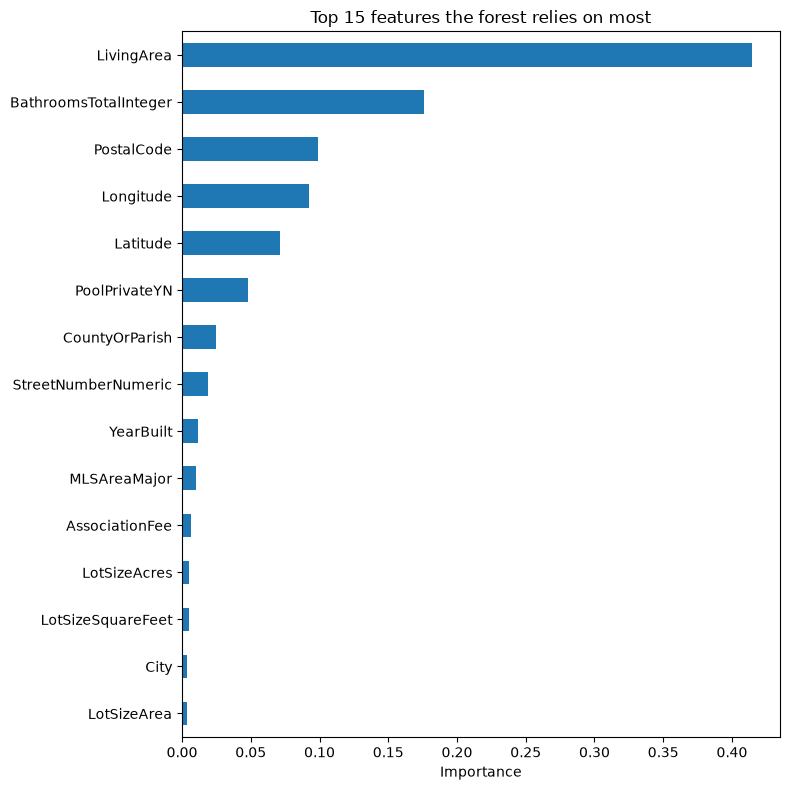

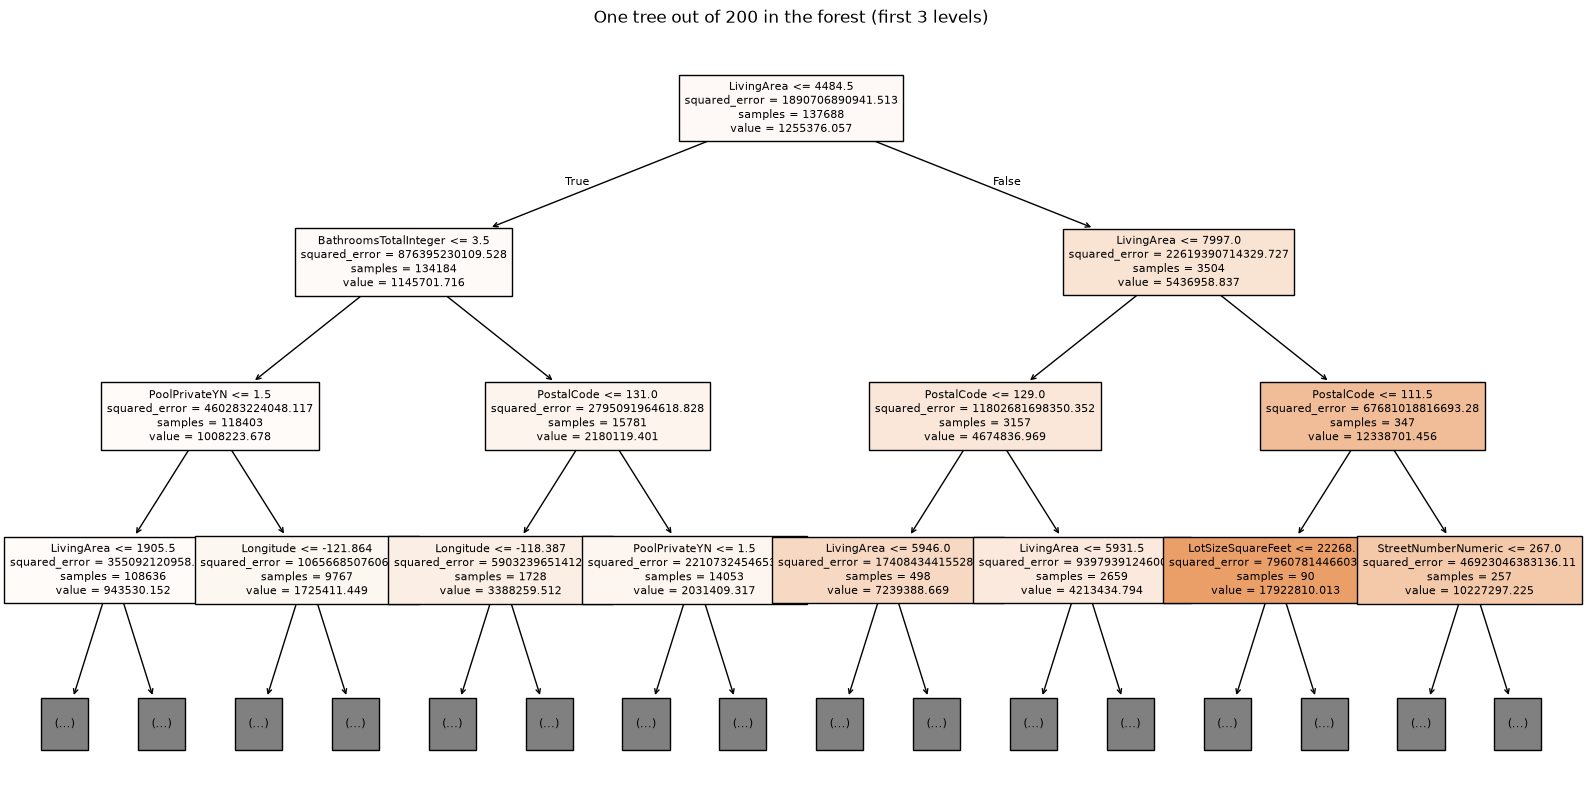

In [5]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 features the forest relies on most')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
tree.plot_tree(rf_model.estimators_[0], max_depth=3, feature_names=X_train.columns, filled=True, fontsize=8)
plt.title('One tree out of 200 in the forest (first 3 levels)')
plt.show()

## Compare to the single tree

Loading the saved decision tree model and scoring it on this exact same `X_test`/`y_test` for a fair,
apples-to-apples comparison (both were fit on the same cleaned features, without `ListPrice`,
`OriginalListPrice`, or the other dropped columns).

In [6]:
import joblib

dt_model = joblib.load('decision_tree_model.pkl')
dt_pred = dt_model.predict(X_test)

comparison = pd.DataFrame({
    'Decision Tree': {
        'MAE': mean_absolute_error(y_test, dt_pred),
        'RMSE': mean_squared_error(y_test, dt_pred) ** 0.5,
        'R2': r2_score(y_test, dt_pred),
    },
    'Random Forest': {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
        'R2': r2_score(y_test, y_pred),
    },
})
comparison

## Save the model

Saving alongside the decision tree model rather than overwriting it, since they're two different models
worth keeping around to compare.

In [7]:
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Saved random_forest_model.pkl")

Saved random_forest_model.pkl
